In [8]:
import numpy as np
import matplotlib.pyplot as plt
import ripser
import persim
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
import gudhi as gd
from gudhi.representations import Landscape, Silhouette, PersistenceImage
import tadasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import networkx as nx
import nibabel as nib
import os
from tqdm import tqdm
from skimage.transform import resize

target_shape = (128, 128, 64)

In [70]:
def compute_persistent_homology(data, max_dim=1, max_radius=1000.0):
    """
    Улучшенная версия вычисления персистентных гомологий для обнаружения большего числа особенностей.
    """
    
    data_reduced = data
    
    # Если входные данные слишком маленькие, добавляем небольшой шум
    if data_reduced.shape[0] == 1:
        noisy_copies = []
        for i in range(9):  
            noise = np.random.normal(0, 0.01, data_reduced.shape)
            noisy_copies.append(data_reduced + noise)
        
        data_reduced = np.vstack([data_reduced] + noisy_copies)
    
    sample_size = min(50, data_reduced.shape[0])
    indices = np.random.choice(data_reduced.shape[0], sample_size, replace=False)
    data_sample = data_reduced[indices]
    
    try:
        metrics = ['euclidean', 'correlation', 'cosine']
        
        for metric in metrics:
            
            dist_matrix = squareform(pdist(data_sample, metric=metric))
            
            if np.count_nonzero(dist_matrix) < dist_matrix.size / 2:
                dist_matrix += np.random.uniform(0, 0.01, dist_matrix.shape)
                np.fill_diagonal(dist_matrix, 0)  
            
            diagrams = ripser.ripser(dist_matrix, maxdim=max_dim, distance_matrix=True, thresh=max_radius)['dgms']
            
            if len(diagrams) > 1 and len(diagrams[1]) > 0:
                return diagrams
        
        dist_matrix = squareform(pdist(data_sample, metric='euclidean'))
        
        if np.max(dist_matrix) > 0:
            dist_matrix = dist_matrix / np.max(dist_matrix) * max_radius
        
        diagrams = ripser.ripser(dist_matrix, maxdim=max_dim, distance_matrix=True, 
                               thresh=max_radius * 2)['dgms']
        
        return diagrams
    except Exception as e:
        print(f"Ошибка при вычислении персистентных гомологий: {e}")
        return [np.array([]) for _ in range(max_dim + 1)]


In [25]:

def create_artificial_anomalies(mri_data, anomaly_ratio=0.2, anomaly_intensity=3.0):
    """
    Создает искусственные аномалии в МРТ данных.
    
    Args:
        mri_data: Исходные МРТ данные
        anomaly_ratio: Доля данных с аномалиями
        anomaly_intensity: Интенсивность аномалий
        
    Returns:
        Данные с аномалиями и список индексов аномальных образцов
    """
    mri_data_anomaly = mri_data.copy()
    num_samples = mri_data.shape[0]
    num_anomalies = int(num_samples * anomaly_ratio)
    
    # Выбираем случайные образцы для внесения аномалий
    anomaly_indices = np.random.choice(num_samples, num_anomalies, replace=False)
    
    for idx in anomaly_indices:
        sample_3d = mri_data[idx].reshape(target_shape)
        
        # Создаем случайную локальную аномалию
        x_center = np.random.randint(20, target_shape[0]-20)
        y_center = np.random.randint(20, target_shape[1]-20)
        z_center = np.random.randint(10, target_shape[2]-10)
        
        radius = np.random.randint(20, 30)
        
        # Создаем шар аномалии
        x, y, z = np.indices((target_shape))
        dist = np.sqrt((x - x_center)**2 + (y - y_center)**2 + (z - z_center)**2)
        anomaly_mask = dist <= radius
        
        if np.random.rand() > 0.5:
            sample_3d[anomaly_mask] *= anomaly_intensity
        else:
            sample_3d[anomaly_mask] /= anomaly_intensity
        
        mri_data_anomaly[idx] = sample_3d.flatten()
    
    return mri_data_anomaly, anomaly_indices


In [88]:
def evaluate_anomaly_detection(mri_data, anomaly_ratio=0.2):
    """
    Исправленная функция оценки качества обнаружения аномалий.
    """

    mri_data_with_anomalies, anomaly_indices = create_artificial_anomalies(mri_data, anomaly_ratio, anomaly_intensity=1000.0)
    
    print(f"Создано {len(anomaly_indices)} аномальных МРТ образцов из {len(mri_data)} всего")
    
    all_diagrams = []
    all_topological_scores = []
    
    for i in tqdm(range(len(mri_data_with_anomalies)), desc="Анализ образцов"):
        sample = mri_data_with_anomalies[i].reshape(1, -1)
        
        try:
            diagrams = compute_persistent_homology(sample, max_dim=1, max_radius=100.0)
            anomaly_score = 0
            
            if len(diagrams) > 1 and len(diagrams[1]) > 0:
                h1_diagram = diagrams[1]
                
                persistences = []
                for j in range(len(h1_diagram)):
                    if isinstance(h1_diagram[j], np.ndarray) and len(h1_diagram[j]) == 2:
                        birth, death = h1_diagram[j]
                        if not np.isinf(death):
                            persistences.append(death - birth)
                
                if persistences:
                    anomaly_score = np.mean(persistences)
            else:
                h0_diagram = diagrams[0]
                
                finite_persistences = []
                for j in range(len(h0_diagram)):
                    if isinstance(h0_diagram[j], np.ndarray) and len(h0_diagram[j]) == 2:
                        birth, death = h0_diagram[j]
                        if not np.isinf(death):
                            finite_persistences.append(death - birth)
                
                if finite_persistences:
                    anomaly_score = np.std(finite_persistences)
                else:
                    anomaly_score = len(h0_diagram) * 0.01
            
            all_diagrams.append(diagrams)
            all_topological_scores.append(anomaly_score)
        except Exception as e:
            print(f"Ошибка при анализе образца {i}: {e}")
            all_diagrams.append(None)
            all_topological_scores.append(0)
    
    all_topological_scores = np.array(all_topological_scores)
    
    true_labels = np.zeros(len(mri_data_with_anomalies))
    true_labels[anomaly_indices] = 1
    
    if np.std(all_topological_scores) < 1e-10:
        print("ВНИМАНИЕ: Все оценки аномальности почти одинаковые. Метрики могут быть ненадежными.")
        all_topological_scores += np.random.normal(0, 1e-5, all_topological_scores.shape)
    
    if np.max(all_topological_scores) > np.min(all_topological_scores):
        normalized_scores = (all_topological_scores - np.min(all_topological_scores)) / (np.max(all_topological_scores) - np.min(all_topological_scores))
    else:
        normalized_scores = np.zeros_like(all_topological_scores)

    from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
    
    try:
        roc_auc = roc_auc_score(true_labels, normalized_scores)
        precision, recall, _ = precision_recall_curve(true_labels, normalized_scores)
        pr_auc = auc(recall, precision)
        
        print(f"\nРезультаты обнаружения аномалий:")
        print(f"ROC AUC: {roc_auc:.4f}")
        print(f"PR AUC: {pr_auc:.4f}")
        
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        from sklearn.metrics import roc_curve
        fpr, tpr, _ = roc_curve(true_labels, normalized_scores)
        plt.plot(fpr, tpr)
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve (AUC = {roc_auc:.4f})')
        
        plt.subplot(1, 3, 2)
        plt.plot(recall, precision)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'PR Curve (AUC = {pr_auc:.4f})')
        
        plt.subplot(1, 3, 3)
        plt.hist(normalized_scores[true_labels == 0], alpha=0.5, bins=20, label='Нормальные')
        plt.hist(normalized_scores[true_labels == 1], alpha=0.5, bins=20, label='Аномальные')
        plt.xlabel('Топологическая оценка аномальности')
        plt.ylabel('Количество образцов')
        plt.legend()
        plt.title('Распределение оценок')
        
        plt.tight_layout()
        plt.savefig('anomaly_detection_evaluation.png')
        plt.close()
        
        threshold = 0.00
        predicted_anomalies = normalized_scores >= threshold
        
        tp_indices = np.where((predicted_anomalies == 1) & (true_labels == 1))[0]
        fn_indices = np.where((predicted_anomalies == 0) & (true_labels == 1))[0]
        fp_indices = np.where((predicted_anomalies == 1) & (true_labels == 0))[0]
        
        fig, axes = plt.subplots(3, 3, figsize=(15, 15))
        
        def plot_example(ax, idx, title):
            sample_3d = mri_data_with_anomalies[idx].reshape(target_shape)
            ax.imshow(sample_3d[:, :, sample_3d.shape[2]//2], cmap='gray')
            ax.set_title(f"{title}\nScore: {normalized_scores[idx]:.4f}")
            ax.axis('off')
        
        # Примеры TP
        for i in range(min(3, len(tp_indices))):
            if i < len(tp_indices):
                plot_example(axes[0, i], tp_indices[i], f"TP {i+1}")
        
        # Примеры FN
        for i in range(min(3, len(fn_indices))):
            if i < len(fn_indices):
                plot_example(axes[1, i], fn_indices[i], f"FN {i+1}")
        
        # Примеры FP
        for i in range(min(3, len(fp_indices))):
            if i < len(fp_indices):
                plot_example(axes[2, i], fp_indices[i], f"FP {i+1}")
        
        plt.tight_layout()
        plt.savefig('anomaly_examples.png')
        plt.close()
        
        return roc_auc, pr_auc, normalized_scores, true_labels
        
    except Exception as e:
        print(f"Ошибка при расчете метрик: {e}")
        return 0, 0, normalized_scores, true_labels


In [ ]:
data_dir = './data/'
target_shape = (128, 128, 64)

def load_mri_images(data_dir):
    images = []
    file_list = [f for f in os.listdir(data_dir) if f.endswith('.nii') or f.endswith('.nii.gz')]
    
    for file_name in tqdm(file_list, desc="Загрузка MRI-изображений"):
        img_path = os.path.join(data_dir, file_name)
        img = nib.load(img_path)
        img_data = img.get_fdata()

        img_resized = resize(img_data, target_shape, anti_aliasing=True)

        img_vector = img_resized.flatten()
        images.append(img_vector)
    
    return np.array(images)

mri_data = load_mri_images(data_dir)


Загрузка MRI-изображений: 100%|██████████| 582/582 [01:59<00:00,  4.85it/s]


In [89]:
# Оценка качества определения аномалий
roc_auc, pr_auc, scores, true_labels = evaluate_anomaly_detection(mri_data[:100], anomaly_ratio=0.3)

print(f"\nИтоговые результаты обнаружения аномалий:")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")

Создано 30 аномальных МРТ образцов из 100 всего


Анализ образцов: 100%|██████████| 100/100 [00:30<00:00,  3.32it/s]



Результаты обнаружения аномалий:
ROC AUC: 0.4250
PR AUC: 0.2506

Итоговые результаты обнаружения аномалий:
ROC AUC: 0.4250
PR AUC: 0.2506


In [80]:
def plot_threshold_selection(normalized_scores, true_labels, anomaly_ratio=0.2):
    """
    Строит график для анализа влияния порога на различные метрики классификации.
    
    Args:
        normalized_scores: Нормализованные оценки аномальности
        true_labels: Истинные метки (1 для аномалий, 0 для нормальных)
        anomaly_ratio: Ожидаемая доля аномалий
    """
    # Создаем диапазон возможных порогов от 0 до 1
    thresholds = np.linspace(0, 1, 100)
    
    # Инициализируем массивы для хранения метрик при каждом пороге
    sensitivities = []  # True Positive Rate (Recall)
    specificities = []  # True Negative Rate
    precisions = []     # Precision
    f1_scores = []      # F1 Score
    accuracies = []     # Accuracy
    
    # Для каждого порога вычисляем метрики
    for threshold in thresholds:
        predicted = normalized_scores >= threshold
        
        # Элементы матрицы ошибок
        TP = np.sum((predicted == 1) & (true_labels == 1))
        FP = np.sum((predicted == 1) & (true_labels == 0))
        TN = np.sum((predicted == 0) & (true_labels == 0))
        FN = np.sum((predicted == 0) & (true_labels == 1))
        
        # Вычисление метрик
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0  # Recall
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
        accuracy = (TP + TN) / (TP + TN + FP + FN)
        
        # Сохраняем метрики
        sensitivities.append(sensitivity)
        specificities.append(specificity)
        precisions.append(precision)
        f1_scores.append(f1)
        accuracies.append(accuracy)
    
    # Находим "автоматический" порог, соответствующий anomaly_ratio
    auto_threshold = np.percentile(normalized_scores, 100 * (1 - anomaly_ratio))
    auto_threshold_index = np.abs(thresholds - auto_threshold).argmin()
    
    # Находим порог, максимизирующий F1-меру
    best_f1_index = np.argmax(f1_scores)
    best_f1_threshold = thresholds[best_f1_index]
    
    # Находим порог, максимизирующий точность
    best_accuracy_index = np.argmax(accuracies)
    best_accuracy_threshold = thresholds[best_accuracy_index]
    
    # Находим порог с оптимальным балансом между чувствительностью и специфичностью
    balance_index = np.argmin(np.abs(np.array(sensitivities) - np.array(specificities)))
    balance_threshold = thresholds[balance_index]
    
    # Создаем график
    plt.figure(figsize=(15, 10))
    
    # График 1: Основные метрики в зависимости от порога
    plt.subplot(2, 2, 1)
    plt.plot(thresholds, sensitivities, label='Чувствительность (TPR)', color='blue')
    plt.plot(thresholds, specificities, label='Специфичность (TNR)', color='green')
    plt.plot(thresholds, precisions, label='Точность (Precision)', color='red')
    plt.plot(thresholds, f1_scores, label='F1-мера', color='purple')
    plt.plot(thresholds, accuracies, label='Общая точность', color='orange')
    
    # Отмечаем различные оптимальные пороги
    plt.axvline(x=auto_threshold, color='black', linestyle='--', 
                label=f'Порог по соотношению ({auto_threshold:.3f})')
    plt.axvline(x=best_f1_threshold, color='purple', linestyle=':', 
                label=f'Макс. F1 ({best_f1_threshold:.3f})')
    plt.axvline(x=balance_threshold, color='gray', linestyle='-.', 
                label=f'Баланс Se/Sp ({balance_threshold:.3f})')
    
    plt.xlabel('Порог')
    plt.ylabel('Значение метрики')
    plt.title('Зависимость метрик от порога классификации')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid(True)
    
    # График 2: ROC-кривая с отмеченными порогами
    plt.subplot(2, 2, 2)
    from sklearn.metrics import roc_curve, roc_auc_score
    fpr, tpr, roc_thresholds = roc_curve(true_labels, normalized_scores)
    roc_auc = roc_auc_score(true_labels, normalized_scores)
    
    plt.plot(fpr, tpr, label=f'ROC кривая (AUC = {roc_auc:.3f})', color='blue')
    plt.plot([0, 1], [0, 1], 'k--')
    
    # Отмечаем точки, соответствующие выбранным порогам
    # Находим ближайшие индексы в массиве roc_thresholds
    auto_index = np.abs(roc_thresholds - auto_threshold).argmin()
    best_f1_index_roc = np.abs(roc_thresholds - best_f1_threshold).argmin()
    balance_index_roc = np.abs(roc_thresholds - balance_threshold).argmin()
    
    plt.scatter(fpr[auto_index], tpr[auto_index], color='black', s=100, label=f'Порог по соотношению')
    plt.scatter(fpr[best_f1_index_roc], tpr[best_f1_index_roc], color='purple', s=100, label=f'Макс. F1')
    plt.scatter(fpr[balance_index_roc], tpr[balance_index_roc], color='gray', s=100, label=f'Баланс Se/Sp')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривая с отмеченными порогами')
    plt.legend(loc='lower right')
    plt.grid(True)
    
    # График 3: PR-кривая с отмеченными порогами
    plt.subplot(2, 2, 3)
    from sklearn.metrics import precision_recall_curve, auc
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(true_labels, normalized_scores)
    pr_auc = auc(recall_curve, precision_curve)
    
    plt.plot(recall_curve, precision_curve, label=f'PR кривая (AUC = {pr_auc:.3f})', color='red')
    
    # Для PR-кривой немного сложнее найти точки, т.к. формат precision_recall_curve отличается
    # Поэтому берем ближайшие точки по значению порога
    if len(pr_thresholds) > 0:  # Обработка случая, когда pr_thresholds пуст
        auto_index_pr = np.abs(pr_thresholds - auto_threshold).argmin()
        best_f1_index_pr = np.abs(pr_thresholds - best_f1_threshold).argmin()
        balance_index_pr = np.abs(pr_thresholds - balance_threshold).argmin()
        
        plt.scatter(recall_curve[auto_index_pr], precision_curve[auto_index_pr], 
                   color='black', s=100, label=f'Порог по соотношению')
        plt.scatter(recall_curve[best_f1_index_pr], precision_curve[best_f1_index_pr], 
                   color='purple', s=100, label=f'Макс. F1')
        plt.scatter(recall_curve[balance_index_pr], precision_curve[balance_index_pr], 
                   color='gray', s=100, label=f'Баланс Se/Sp')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('PR-кривая с отмеченными порогами')
    plt.legend(loc='upper right')
    plt.grid(True)
    
    # График 4: Распределение оценок с отмеченными порогами
    plt.subplot(2, 2, 4)
    plt.hist(normalized_scores[true_labels == 0], bins=30, alpha=0.5, color='green', label='Нормальные')
    plt.hist(normalized_scores[true_labels == 1], bins=30, alpha=0.5, color='red', label='Аномальные')
    
    plt.axvline(x=auto_threshold, color='black', linestyle='--', 
               label=f'Порог по соотношению ({auto_threshold:.3f})')
    plt.axvline(x=best_f1_threshold, color='purple', linestyle=':', 
               label=f'Макс. F1 ({best_f1_threshold:.3f})')
    plt.axvline(x=balance_threshold, color='gray', linestyle='-.', 
               label=f'Баланс Se/Sp ({balance_threshold:.3f})')
    
    plt.xlabel('Оценка аномальности')
    plt.ylabel('Количество образцов')
    plt.title('Распределение оценок с отмеченными порогами')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('threshold_selection.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Выводим сводную таблицу метрик для каждого порога
    print("\nСравнение различных порогов:")
    headers = ["Порог", "Описание", "Sens.", "Spec.", "Prec.", "F1", "Acc."]
    
    table_data = [
        [f"{auto_threshold:.3f}", "По соотношению аномалий", 
         f"{sensitivities[auto_threshold_index]:.3f}", 
         f"{specificities[auto_threshold_index]:.3f}",
         f"{precisions[auto_threshold_index]:.3f}", 
         f"{f1_scores[auto_threshold_index]:.3f}", 
         f"{accuracies[auto_threshold_index]:.3f}"],
        
        [f"{best_f1_threshold:.3f}", "Максимум F1-меры", 
         f"{sensitivities[best_f1_index]:.3f}", 
         f"{specificities[best_f1_index]:.3f}",
         f"{precisions[best_f1_index]:.3f}", 
         f"{f1_scores[best_f1_index]:.3f}", 
         f"{accuracies[best_f1_index]:.3f}"],
        
        [f"{balance_threshold:.3f}", "Баланс Se/Sp", 
         f"{sensitivities[balance_index]:.3f}", 
         f"{specificities[balance_index]:.3f}",
         f"{precisions[balance_index]:.3f}", 
         f"{f1_scores[balance_index]:.3f}", 
         f"{accuracies[balance_index]:.3f}"],
        
        [f"{best_accuracy_threshold:.3f}", "Максимум точности", 
         f"{sensitivities[best_accuracy_index]:.3f}", 
         f"{specificities[best_accuracy_index]:.3f}",
         f"{precisions[best_accuracy_index]:.3f}", 
         f"{f1_scores[best_accuracy_index]:.3f}", 
         f"{accuracies[best_accuracy_index]:.3f}"]
    ]
    
    # Определим максимальную ширину для каждого столбца
    col_widths = [max(len(row[i]) for row in [headers] + table_data) for i in range(len(headers))]
    
    # Выводим заголовок таблицы
    header_line = " | ".join(h.ljust(col_widths[i]) for i, h in enumerate(headers))
    print(header_line)
    print("-" * len(header_line))
    
    # Выводим данные таблицы
    for row in table_data:
        print(" | ".join(cell.ljust(col_widths[i]) for i, cell in enumerate(row)))
    
    return {
        'auto_threshold': auto_threshold,
        'best_f1_threshold': best_f1_threshold,
        'balance_threshold': balance_threshold,
        'best_accuracy_threshold': best_accuracy_threshold
    }


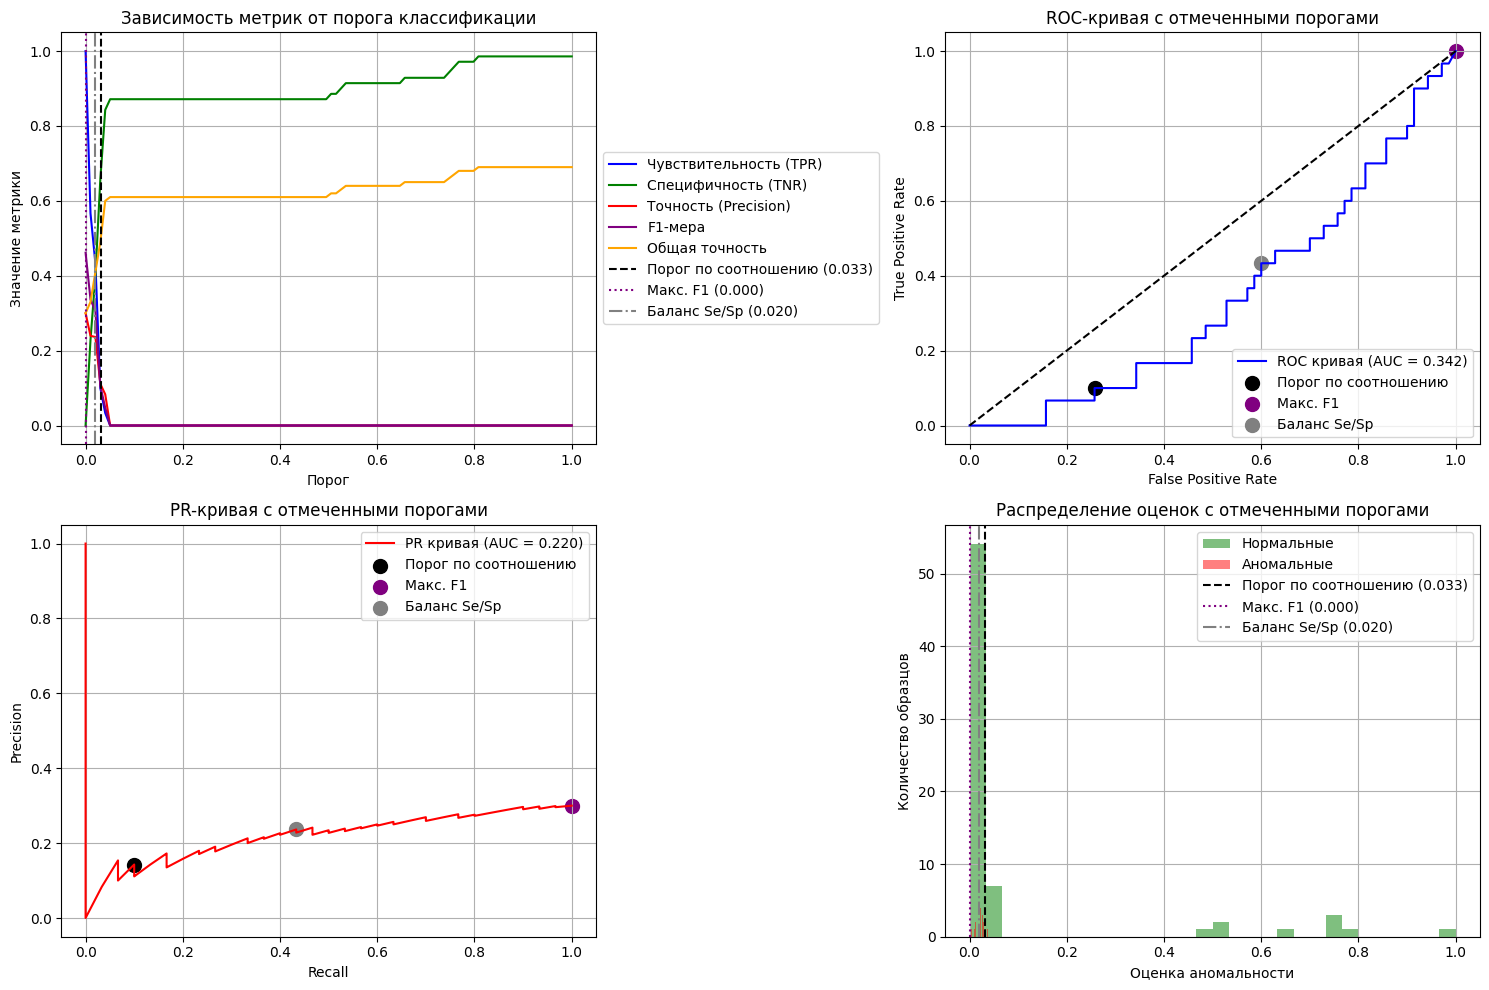


Сравнение различных порогов:
Порог | Описание                | Sens. | Spec. | Prec. | F1    | Acc. 
-----------------------------------------------------------------------
0.033 | По соотношению аномалий | 0.100 | 0.657 | 0.111 | 0.105 | 0.490
0.000 | Максимум F1-меры        | 1.000 | 0.000 | 0.300 | 0.462 | 0.300
0.020 | Баланс Se/Sp            | 0.433 | 0.400 | 0.236 | 0.306 | 0.410
0.808 | Максимум точности       | 0.000 | 0.986 | 0.000 | 0.000 | 0.690

Рекомендуемый порог (максимум F1-меры): 0.0000

Матрица ошибок с оптимальным порогом:
[[ 0 70]
 [ 0 30]]

Отчет о классификации с оптимальным порогом:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        70
         1.0       0.30      1.00      0.46        30

    accuracy                           0.30       100
   macro avg       0.15      0.50      0.23       100
weighted avg       0.09      0.30      0.14       100



/Users/dasidorov03/.pyenv/versions/3.11.4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/dasidorov03/.pyenv/versions/3.11.4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/dasidorov03/.pyenv/versions/3.11.4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

In [83]:
# Предположим, что у вас уже есть результаты:
# roc_auc, pr_auc, normalized_scores, true_labels = evaluate_anomaly_detection(mri_data, anomaly_ratio=0.2)

# Теперь проведем анализ выбора порога
thresholds = plot_threshold_selection(scores, true_labels, anomaly_ratio=0.2)

# Выберем порог, который максимизирует F1-меру
best_threshold = thresholds['best_f1_threshold']
print(f"\nРекомендуемый порог (максимум F1-меры): {best_threshold:.4f}")

# Применим выбранный порог
predicted_anomalies = scores >= best_threshold

# Оценка с новым порогом
from sklearn.metrics import classification_report, confusion_matrix

print("\nМатрица ошибок с оптимальным порогом:")
print(confusion_matrix(true_labels, predicted_anomalies))

print("\nОтчет о классификации с оптимальным порогом:")
print(classification_report(true_labels, predicted_anomalies))
